In [1]:
import pandas as pd

In [2]:
import seaborn as sns

In [3]:
import matplotlib.pyplot as plt

In [4]:
import numpy as np

In [5]:
import warnings

In [6]:
warnings.filterwarnings("ignore")

In [7]:
df=pd.read_csv(r"E:\My laptop docs\Desktop\ML_DataSets\enhanced_customer_purchase_dataset.csv")
df

,customer_id,customer_name,purchase_year,purchase_month,purchase_day,purchase_hour,day_of_week,is_weekend,salary,card_form,exchange_level,will_buy_product
0,12965,Kimberly Davis,2023,2,24,0,Friday,0,84458,3,3,0
1,10969,Stephanie King,2023,7,10,6,Monday,0,56071,1,1,0
2,11385,Andrea White,2023,10,27,3,Friday,0,62046,2,3,0
3,11233,Tabitha Flores,2023,2,11,23,Saturday,1,63849,2,2,1
4,12996,Joanna Moran,2023,11,27,7,Monday,0,69402,2,3,1
...,...,...,...,...,...,...,...,...,...,...,...,...
3145,12414,Katherine Becker,2024,7,28,2,Sunday,1,61802,2,3,1
3146,11095,Stacey Lopez,2023,11,12,4,Sunday,1,45308,1,3,0
3147,11130,Olivia Murray,2023,4,20,16,Thursday,0,52792,1,2,1
3148,11294,Julie Mckay,2024,10,8,18,Tuesday,0,56479,1,1,1


In [8]:
df.head()

,customer_id,customer_name,purchase_year,purchase_month,purchase_day,purchase_hour,day_of_week,is_weekend,salary,card_form,exchange_level,will_buy_product
0,12965,Kimberly Davis,2023,2,24,0,Friday,0,84458,3,3,0
1,10969,Stephanie King,2023,7,10,6,Monday,0,56071,1,1,0
2,11385,Andrea White,2023,10,27,3,Friday,0,62046,2,3,0
3,11233,Tabitha Flores,2023,2,11,23,Saturday,1,63849,2,2,1
4,12996,Joanna Moran,2023,11,27,7,Monday,0,69402,2,3,1


In [9]:
df.shape

(3150, 12)

In [10]:
df.columns

Index(['customer_id', 'customer_name', 'purchase_year', 'purchase_month',
       'purchase_day', 'purchase_hour', 'day_of_week', 'is_weekend', 'salary',
       'card_form', 'exchange_level', 'will_buy_product'],
      dtype='str')

In [11]:
df.dtypes

customer_id         int64
customer_name         str
purchase_year       int64
purchase_month      int64
purchase_day        int64
purchase_hour       int64
day_of_week           str
is_weekend          int64
salary              int64
card_form           int64
exchange_level      int64
will_buy_product    int64
dtype: object

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3150 entries, 0 to 3149
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   customer_id       3150 non-null   int64
 1   customer_name     3150 non-null   str  
 2   purchase_year     3150 non-null   int64
 3   purchase_month    3150 non-null   int64
 4   purchase_day      3150 non-null   int64
 5   purchase_hour     3150 non-null   int64
 6   day_of_week       3150 non-null   str  
 7   is_weekend        3150 non-null   int64
 8   salary            3150 non-null   int64
 9   card_form         3150 non-null   int64
 10  exchange_level    3150 non-null   int64
 11  will_buy_product  3150 non-null   int64
dtypes: int64(10), str(2)
memory usage: 295.4 KB


### NANS

In [13]:
df.isna().sum()

customer_id         0
customer_name       0
purchase_year       0
purchase_month      0
purchase_day        0
purchase_hour       0
day_of_week         0
is_weekend          0
salary              0
card_form           0
exchange_level      0
will_buy_product    0
dtype: int64

In [14]:
df.isna().sum().sum()

np.int64(0)

In [15]:
df=df.drop(["customer_id","customer_name"],axis=1)
df

,purchase_year,purchase_month,purchase_day,purchase_hour,day_of_week,is_weekend,salary,card_form,exchange_level,will_buy_product
0,2023,2,24,0,Friday,0,84458,3,3,0
1,2023,7,10,6,Monday,0,56071,1,1,0
2,2023,10,27,3,Friday,0,62046,2,3,0
3,2023,2,11,23,Saturday,1,63849,2,2,1
4,2023,11,27,7,Monday,0,69402,2,3,1
...,...,...,...,...,...,...,...,...,...,...
3145,2024,7,28,2,Sunday,1,61802,2,3,1
3146,2023,11,12,4,Sunday,1,45308,1,3,0
3147,2023,4,20,16,Thursday,0,52792,1,2,1
3148,2024,10,8,18,Tuesday,0,56479,1,1,1


<function matplotlib.pyplot.show(close=None, block=None)>

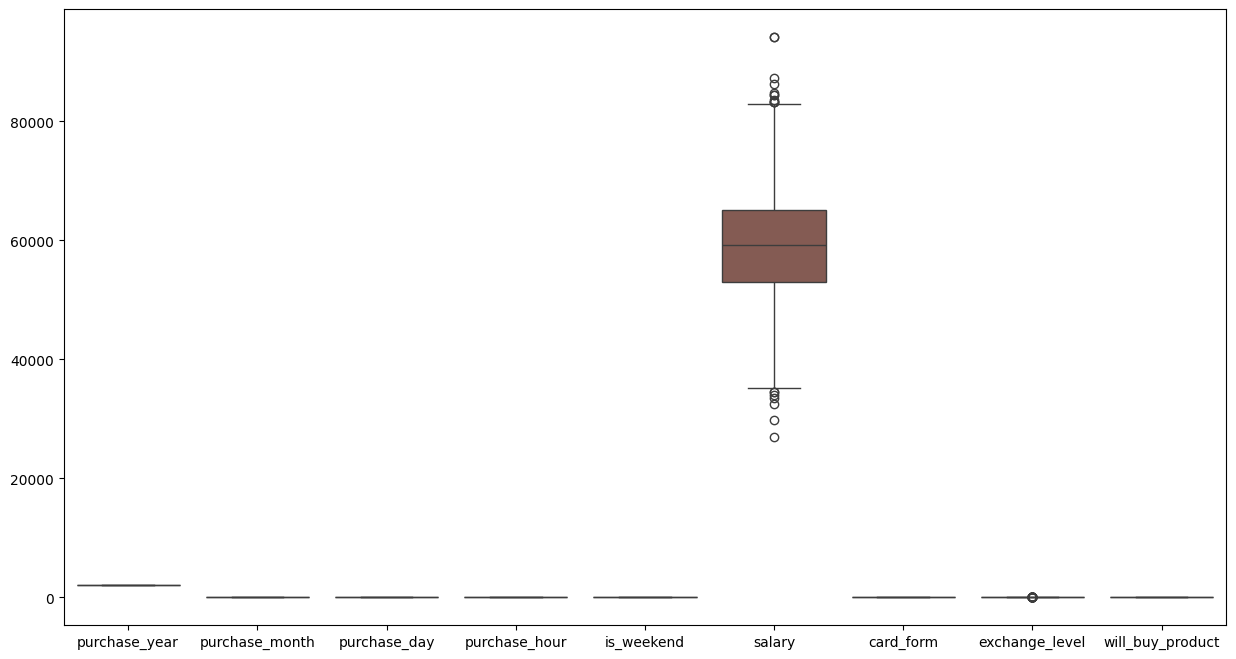

In [16]:
plt.figure(figsize=(15,8))
sns.boxplot(df)
plt.show

### IQR METHOD

In [17]:
q1 = df["salary"].quantile(0.25)
q3 = df["salary"].quantile(0.75)
iqr = q3 - q1
lower = q1 - (1.5 * iqr)
upper = q3 + (1.5 * iqr)
df["salary"] = df["salary"].map(lambda x : lower if x < lower else upper if x > upper else x)

<function matplotlib.pyplot.show(close=None, block=None)>

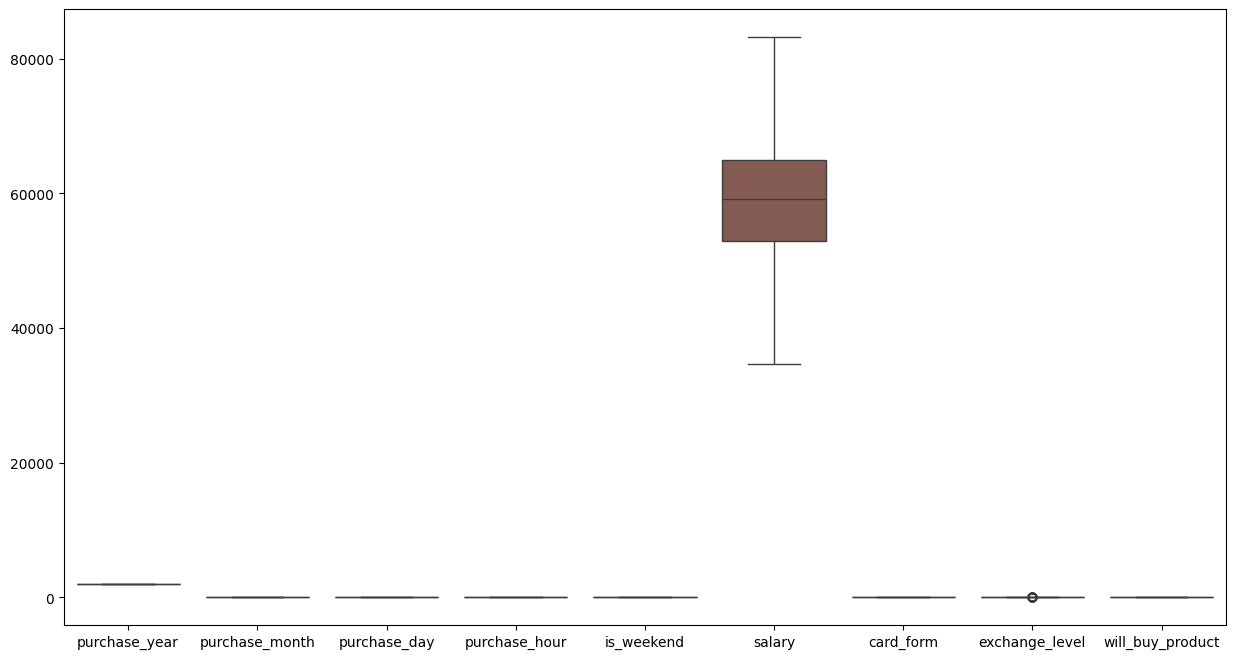

In [18]:
plt.figure(figsize=(15,8))
sns.boxplot(df)
plt.show

### ENCODING

In [19]:
df.head()

,purchase_year,purchase_month,purchase_day,purchase_hour,day_of_week,is_weekend,salary,card_form,exchange_level,will_buy_product
0,2023,2,24,0,Friday,0,83241.25,3,3,0
1,2023,7,10,6,Monday,0,56071.00,1,1,0
2,2023,10,27,3,Friday,0,62046.00,2,3,0
3,2023,2,11,23,Saturday,1,63849.00,2,2,1
4,2023,11,27,7,Monday,0,69402.00,2,3,1


In [20]:
df=pd.get_dummies(df,dtype="int")
df

,purchase_year,purchase_month,purchase_day,purchase_hour,is_weekend,salary,card_form,exchange_level,will_buy_product,day_of_week_Friday,day_of_week_Monday,day_of_week_Saturday,day_of_week_Sunday,day_of_week_Thursday,day_of_week_Tuesday,day_of_week_Wednesday
0,2023,2,24,0,0,83241.25,3,3,0,1,0,0,0,0,0,0
1,2023,7,10,6,0,56071.00,1,1,0,0,1,0,0,0,0,0
2,2023,10,27,3,0,62046.00,2,3,0,1,0,0,0,0,0,0
3,2023,2,11,23,1,63849.00,2,2,1,0,0,1,0,0,0,0
4,2023,11,27,7,0,69402.00,2,3,1,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3145,2024,7,28,2,1,61802.00,2,3,1,0,0,0,1,0,0,0
3146,2023,11,12,4,1,45308.00,1,3,0,0,0,0,1,0,0,0
3147,2023,4,20,16,0,52792.00,1,2,1,0,0,0,0,1,0,0
3148,2024,10,8,18,0,56479.00,1,1,1,0,0,0,0,0,1,0


### DATA SEPERATION

In [21]:
X=df.drop(["will_buy_product"],axis=1)
X

,purchase_year,purchase_month,purchase_day,purchase_hour,is_weekend,salary,card_form,exchange_level,day_of_week_Friday,day_of_week_Monday,day_of_week_Saturday,day_of_week_Sunday,day_of_week_Thursday,day_of_week_Tuesday,day_of_week_Wednesday
0,2023,2,24,0,0,83241.25,3,3,1,0,0,0,0,0,0
1,2023,7,10,6,0,56071.00,1,1,0,1,0,0,0,0,0
2,2023,10,27,3,0,62046.00,2,3,1,0,0,0,0,0,0
3,2023,2,11,23,1,63849.00,2,2,0,0,1,0,0,0,0
4,2023,11,27,7,0,69402.00,2,3,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3145,2024,7,28,2,1,61802.00,2,3,0,0,0,1,0,0,0
3146,2023,11,12,4,1,45308.00,1,3,0,0,0,1,0,0,0
3147,2023,4,20,16,0,52792.00,1,2,0,0,0,0,1,0,0
3148,2024,10,8,18,0,56479.00,1,1,0,0,0,0,0,1,0


In [22]:
y=df["will_buy_product"]
y

0       0
1       0
2       0
3       1
4       1
       ..
3145    1
3146    0
3147    1
3148    1
3149    1
Name: will_buy_product, Length: 3150, dtype: int64

### IMBLANCE

In [23]:
y.value_counts()

will_buy_product
1    2242
0     908
Name: count, dtype: int64

In [24]:
from imblearn.over_sampling import RandomOverSampler

In [25]:
ros=RandomOverSampler()

In [26]:
ros

,sampling_strategy,'auto'
,random_state,None
,shrinkage,None


In [27]:
X_ros,y_ros=ros.fit_resample(X,y)

In [28]:
X.shape

(3150, 15)

In [29]:
X_ros.shape

(4484, 15)

In [30]:
y.value_counts()

will_buy_product
1    2242
0     908
Name: count, dtype: int64

In [31]:
y_ros.value_counts()

will_buy_product
0    2242
1    2242
Name: count, dtype: int64

<Axes: xlabel='will_buy_product'>

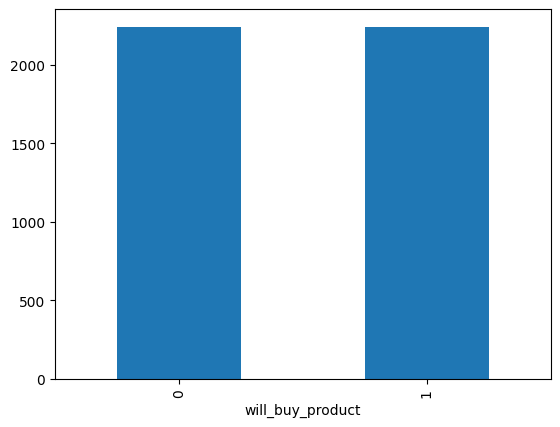

In [32]:
y_ros.value_counts().plot(kind="bar")

### DATA SPLITTING

In [33]:
from sklearn.model_selection import train_test_split

In [34]:
X_train,X_test,y_train,y_test=train_test_split(X_ros,y_ros,test_size=0.20,random_state=42)

In [35]:
X_train.shape

(3587, 15)

In [36]:
X_test.shape

(897, 15)

In [37]:
X_ros.shape

(4484, 15)

### FEATURE SCALING

#### STANDRADIZATION

In [38]:
from sklearn.preprocessing import StandardScaler

In [39]:
ss=StandardScaler()

In [40]:
ss

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [41]:

X_train = ss.fit_transform(X_train)
X_test = ss.transform(X_test)

In [42]:
X_train

array([[-0.99416256,  1.02641862, -0.92947687, ..., -0.44279268,
        -0.40758415, -0.41545809],
       [ 1.00587171,  1.60295536,  0.56519297, ..., -0.44279268,
        -0.40758415, -0.41545809],
       [ 1.00587171,  1.60295536,  0.22026916, ..., -0.44279268,
        -0.40758415,  2.40698164],
       ...,
       [ 1.00587171,  1.02641862,  1.37001518, ..., -0.44279268,
        -0.40758415, -0.41545809],
       [-0.99416256,  0.44988189,  0.33524376, ..., -0.44279268,
        -0.40758415, -0.41545809],
       [-0.99416256, -0.70319159, -1.73429908, ..., -0.44279268,
        -0.40758415, -0.41545809]], shape=(3587, 15))

In [43]:
X_test

array([[ 1.00587171, -0.12665485,  0.68016757, ..., -0.44279268,
        -0.40758415, -0.41545809],
       [ 1.00587171, -1.27972832, -1.38937528, ..., -0.44279268,
        -0.40758415, -0.41545809],
       [-0.99416256, -1.56799669,  0.10529456, ..., -0.44279268,
         2.45348109, -0.41545809],
       ...,
       [ 1.00587171, -0.99145996, -1.61932448, ..., -0.44279268,
        -0.40758415, -0.41545809],
       [-0.99416256, -1.56799669,  0.10529456, ..., -0.44279268,
         2.45348109, -0.41545809],
       [ 1.00587171, -0.99145996, -0.81450226, ..., -0.44279268,
        -0.40758415, -0.41545809]], shape=(897, 15))

In [44]:
X_train.mean()

np.float64(-6.853128891534712e-15)

In [45]:
X_test.mean()

np.float64(0.005287475009995164)

In [46]:
X_train.std()

np.float64(1.0)

In [47]:
X_test.std()

np.float64(0.9979776792528512)

In [48]:
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [49]:
models = {
    "Logistic Regression": LogisticRegression(),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier()
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    
    print(f"{name} Accuracy: {acc}")

Logistic Regression Accuracy: 0.6064659977703456
KNN Accuracy: 0.6789297658862876
Decision Tree Accuracy: 0.8216276477146043
Random Forest Accuracy: 0.8584169453734671


In [50]:
best_model = RandomForestClassifier()
best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[404  34]
 [ 95 364]]

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.92      0.86       438
           1       0.91      0.79      0.85       459

    accuracy                           0.86       897
   macro avg       0.86      0.86      0.86       897
weighted avg       0.86      0.86      0.86       897



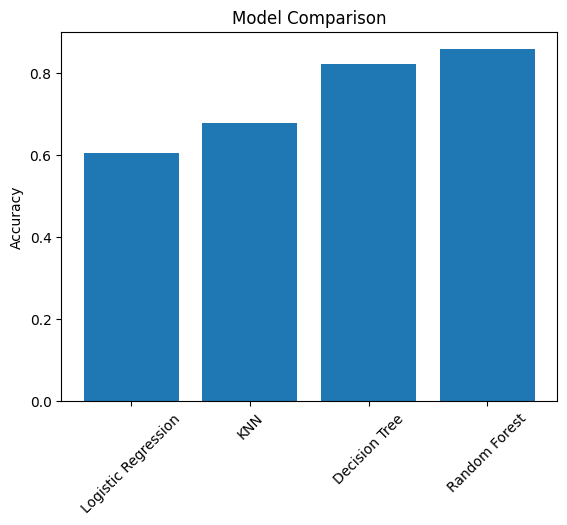

In [51]:
plt.bar(results.keys(), results.values())
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)
plt.show()

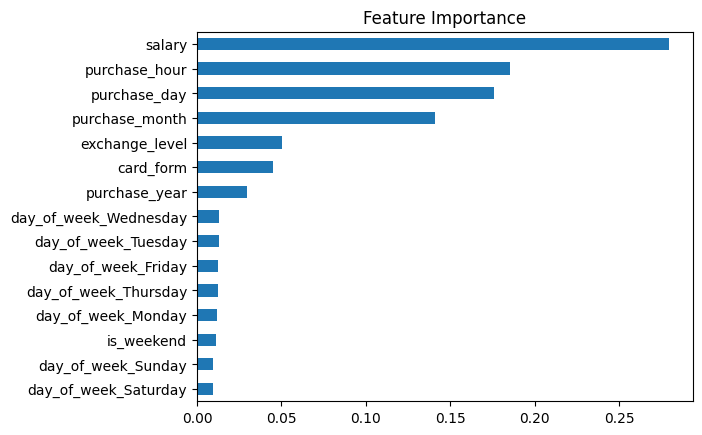

In [52]:
importances = best_model.feature_importances_
feature_names = X.columns

feat_imp = pd.Series(importances, index=feature_names)
feat_imp.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()